# Here I want to investigate antibody reactivity to other genera / species

In [68]:
import pandas as pd 

meta = pd.read_csv('lassa_library_sequences_species_standardized_070726_ICTV_corrected.csv')

df = pd.read_csv('long_091826.csv')

In [69]:
species_unique_pep_count = df.groupby('species')['peptide'].nunique().reset_index()
species_unique_pep_count = species_unique_pep_count.rename(columns={'peptide':'unique_reactive_peps_in_cohort'})

In [70]:
reactive_peps_per_species = df.groupby(['species', 'cohort', 'individual']).agg(
    sum_peps_reactive = ('reactive', 'sum'),
).reset_index()

In [71]:
reactive_peps_per_species_cohort_summary = reactive_peps_per_species.groupby(['species', 'cohort']).agg(
    mean_cohort_reactive_species_peps = ('sum_peps_reactive', 'mean'), 
    median_cohort_reactive_species_peps = ('sum_peps_reactive', 'median'),
    max_cohort_individual_reactive_species_peps = ('sum_peps_reactive', 'max'), 
    sum_cohort_reactive_species_peps = ('sum_peps_reactive', 'sum'), 
).round(1).reset_index()

In [72]:
meta_number_peps_per_species = meta.groupby('species').size().reset_index()

In [73]:
meta_number_peps_per_species = meta_number_peps_per_species.rename(columns={0:'number_peps_in_library'})

In [122]:
meta_number_peps_per_species.sort_values('number_peps_in_library', ascending=False).head(15)

,species,number_peps_in_library
129,Mammarenavirus lassaense,4494
241,Orthonairovirus haemorrhagiae,2524
119,Mammarenavirus choriomeningitidis,2267
185,Orthoflavivirus denguei,2050
464,unidentified Reptarenavirus,1418
173,Nairoviridae sp.,1160
237,Orthonairovirus erveense,1134
155,Mammarenavirus wenzhouense,864
134,Mammarenavirus lunaense,684
439,Uukuvirus uukuniemiense,663


In [74]:
reactive_peps_per_species_cohort_summary = reactive_peps_per_species_cohort_summary.merge(meta_number_peps_per_species, on='species', how='left')
reactive_peps_per_species_cohort_summary = reactive_peps_per_species_cohort_summary.merge(species_unique_pep_count, on='species', how='left')

In [75]:
reactive_peps_per_species_cohort_summary['unique_reactive_peps_in_cohort_normalized_to_library'] = (reactive_peps_per_species_cohort_summary['unique_reactive_peps_in_cohort'] / reactive_peps_per_species_cohort_summary['number_peps_in_library'] * 100).round(1)

In [76]:
reactive_peps_per_species_cohort_summary['mean_perc_cohort_reactive_species_peps_normalized_to_library'] = (reactive_peps_per_species_cohort_summary['mean_cohort_reactive_species_peps'] / reactive_peps_per_species_cohort_summary['number_peps_in_library'] * 100).round(1)

In [124]:
reactive_peps_per_species_cohort_summary.sort_values(by=['mean_cohort_reactive_species_peps', 'max_cohort_individual_reactive_species_peps'], ascending=False).head(20)

,species,cohort,mean_cohort_reactive_species_peps,median_cohort_reactive_species_peps,max_cohort_individual_reactive_species_peps,sum_cohort_reactive_species_peps,number_peps_in_library,unique_reactive_peps_in_cohort,unique_reactive_peps_in_cohort_normalized_to_library,mean_perc_cohort_reactive_species_peps_normalized_to_library
181,Mammarenavirus lassaense,SL,7.4,7.0,27,2924,4494,76,1.7,0.2
365,Orthonairovirus haemorrhagiae,SL,3.3,3.0,12,1327,2524,39,1.5,0.1
269,Orthoflavivirus denguei,SL,2.9,3.0,11,1139,2050,32,1.6,0.1
249,Nairoviridae sp.,SL,1.9,2.0,6,759,1160,20,1.7,0.2
167,Mammarenavirus choriomeningitidis,SL,1.8,2.0,7,718,2267,16,0.7,0.1
357,Orthonairovirus erveense,SL,1.3,1.0,8,515,1134,17,1.5,0.1
733,unidentified Reptarenavirus,SL,1.2,1.0,4,474,1418,14,1.0,0.1
191,Mammarenavirus lunaense,SL,1.1,1.0,6,439,684,10,1.5,0.2
649,Trypanosoma cruzi,SL,1.1,1.0,6,443,471,13,2.8,0.2
391,Orthonairovirus nairobiense,SL,1.1,1.0,4,441,333,7,2.1,0.3


## plot the 

In [78]:
reactive_peps_per_species_cohort_summary.sort_values(by=['max_cohort_individual_reactive_species_peps'], ascending=False).head(5)

,species,cohort,mean_cohort_reactive_species_peps,median_cohort_reactive_species_peps,max_cohort_individual_reactive_species_peps,sum_cohort_reactive_species_peps,number_peps_in_library,unique_reactive_peps_in_cohort,unique_reactive_peps_in_cohort_normalized_to_library,mean_perc_cohort_reactive_species_peps_normalized_to_library
181,Mammarenavirus lassaense,SL,7.4,7.0,27,2924,4494,76,1.7,0.2
365,Orthonairovirus haemorrhagiae,SL,3.3,3.0,12,1327,2524,39,1.5,0.1
269,Orthoflavivirus denguei,SL,2.9,3.0,11,1139,2050,32,1.6,0.1
357,Orthonairovirus erveense,SL,1.3,1.0,8,515,1134,17,1.5,0.1
167,Mammarenavirus choriomeningitidis,SL,1.8,2.0,7,718,2267,16,0.7,0.1


In [79]:
reactive_peps_per_species_cohort_summary.loc[reactive_peps_per_species_cohort_summary['species']=='Orthoebolavirus zairense']

,species,cohort,mean_cohort_reactive_species_peps,median_cohort_reactive_species_peps,max_cohort_individual_reactive_species_peps,sum_cohort_reactive_species_peps,number_peps_in_library,unique_reactive_peps_in_cohort,unique_reactive_peps_in_cohort_normalized_to_library,mean_perc_cohort_reactive_species_peps_normalized_to_library
266,Orthoebolavirus zairense,HBDB,0.0,0.0,0,0,219,3,1.4,0.0
267,Orthoebolavirus zairense,SL,0.3,0.0,2,106,219,3,1.4,0.1


In [113]:
reactive_peps_per_species_cohort_summary.sort_values(by=['sum_cohort_reactive_species_peps'], ascending=False).head(5)

,species,cohort,mean_cohort_reactive_species_peps,median_cohort_reactive_species_peps,max_cohort_individual_reactive_species_peps,sum_cohort_reactive_species_peps,number_peps_in_library,unique_reactive_peps_in_cohort,unique_reactive_peps_in_cohort_normalized_to_library,mean_perc_cohort_reactive_species_peps_normalized_to_library
181,Mammarenavirus lassaense,SL,7.4,7.0,27,2924,4494,76,1.7,0.2
365,Orthonairovirus haemorrhagiae,SL,3.3,3.0,12,1327,2524,39,1.5,0.1
269,Orthoflavivirus denguei,SL,2.9,3.0,11,1139,2050,32,1.6,0.1
249,Nairoviridae sp.,SL,1.9,2.0,6,759,1160,20,1.7,0.2
167,Mammarenavirus choriomeningitidis,SL,1.8,2.0,7,718,2267,16,0.7,0.1


## clustering peptides within genera to identify distinct viral reactivity regions rather than redundant peptide recognition 

## focusing on CCHFV and DENV

### first just sum reactive peptides for each individual per species and show in heatmap

In [92]:
df_cc = df.loc[df['species'] == 'Orthonairovirus haemorrhagiae']

df_denv = df.loc[df['species'] == 'Orthoflavivirus denguei']

df_concat = pd.concat([df_cc, df_denv], axis=0)

In [97]:
df_concat_sum_peps_per_protein = df_concat.groupby(['individual', 'species']).agg(
    sum_reactive = ('reactive', 'sum')
).reset_index()

In [98]:
df_concat_sum_peps_per_protein

,individual,species,sum_reactive
0,C-109-1_5_B3,Orthoflavivirus denguei,1
1,C-109-1_5_B3,Orthonairovirus haemorrhagiae,3
2,C-109-2_5_B5,Orthoflavivirus denguei,3
3,C-109-2_5_B5,Orthonairovirus haemorrhagiae,4
4,C-109-3_4_E7,Orthoflavivirus denguei,3
...,...,...,...
963,S-512_SA3_G9,Orthonairovirus haemorrhagiae,5
964,S-513_SA3_I2,Orthoflavivirus denguei,1
965,S-513_SA3_I2,Orthonairovirus haemorrhagiae,4
966,S-514_SA3_C8,Orthoflavivirus denguei,2


In [99]:
df_concat_wide = df_concat_sum_peps_per_protein.pivot(index='species', columns='individual', values='sum_reactive')

In [100]:
c_cols = [col for col in df_concat_wide.columns if col.startswith('C-')]
s_cols = [col for col in df_concat_wide.columns if col.startswith('S-')]
hbdb_cols = [col for col in df_concat_wide.columns if col.startswith('HBDB-')]

ordered_cols = c_cols + s_cols + hbdb_cols

df_concat_wide = df_concat_wide[ordered_cols]

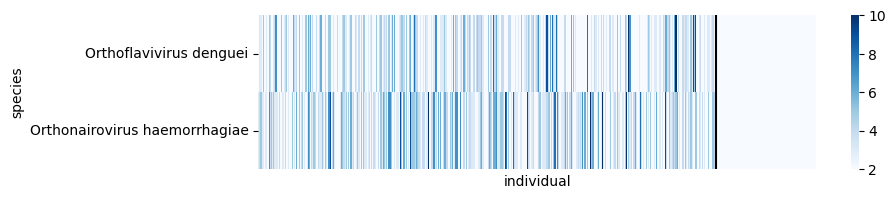

In [110]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 2))

ax = sns.heatmap(df_concat_wide, annot=False, cmap='Blues', vmin=2, vmax=10, xticklabels=False)

ax.axvline(x=len(c_cols + s_cols), color='black', linewidth=1.5)

plt.show()


## now focus on individual species with protein_std groups

In [91]:
df_cc_sum_peps_per_protein = df_cc.groupby(['individual']).agg(
    sum_reactive = ('reactive', 'sum')
).reset_index()

In [82]:
df_cc_sum_peps_per_protein = df_cc.groupby(['protein_std', 'individual']).agg(
    sum_reactive = ('reactive', 'sum')
).reset_index()

In [83]:
df_cc_wide = df_cc_sum_peps_per_protein.pivot(index='protein_std', columns='individual', values='sum_reactive')

In [84]:
c_cols = [col for col in df_cc_wide.columns if col.startswith('C-')]
s_cols = [col for col in df_cc_wide.columns if col.startswith('S-')]
hbdb_cols = [col for col in df_cc_wide.columns if col.startswith('HBDB-')]

ordered_cols = c_cols + s_cols + hbdb_cols

df_cc_wide = df_cc_wide[ordered_cols]

In [85]:
df_cc_wide 

individual,C-109-1_5_B3,C-109-2_5_B5,C-109-3_4_E7,C-110-1_2_A5,C-110-2_3_F8,C-110-3_2_E6,C-111-1_2_H8,C-111-2_3_I5,C-111-3_3_I6,C-112-1_3_B3,...,HBDB-097,HBDB-098,HBDB-099,HBDB-100,HBDB-102,HBDB-106,HBDB-107,HBDB-109,HBDB-111,HBDB-115
protein_std,,,,,,,,,,,,,,,,,,,,,
glycoprotein,3,4,5,3,3,0,2,3,1,7,...,0,0,0,0,0,0,0,0,0,0
nucleoprotein,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
polymerase,0,0,0,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


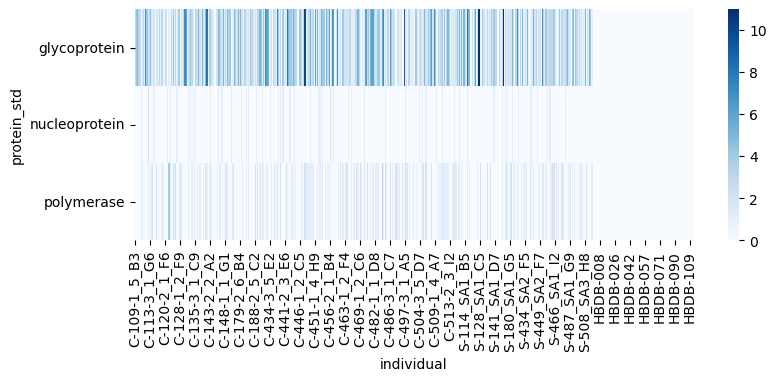

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 3))
sns.heatmap(df_cc_wide, annot=False, cmap='Blues')

plt.show()
